# Passive Evaluation

In [7]:
from pathlib import Path
from typing import cast, Dict

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import xml.etree.ElementTree as ET
from great_tables import GT, loc

from create_polar_dataframe import build_run_level_df, load_all_runs
from plot_style import FONTS, COLOR_PALLETTE


## Parsing Performance Test Results

In [ ]:
def build_aggregate_jmeter_report_df(path: Path) -> pl.DataFrame:
    """
    Build the aggregate report DataFrame based on the JMeter aggregate report.

    Args:
        path (Path): Path to the aggregate-report XML file.

    Returns:
        pl.DataFrame: Columns:
            - label: The name of the sample.
            - samples: The count of samples.
            - average (ms): The average response time in milliseconds.
            - median (ms): The median response time in milliseconds.
            - min (ms): The minimum response time in milliseconds.
            - max (ms): The maximum response time in milliseconds.
            - error_pct (%): The percentage of failed requests.
            - _start: The start timestamp in milliseconds.
            - _end: The end timestamp in milliseconds.
            - throughput_per_sec (requests/sec): The throughput in requests per
                second.
    """

    def parse_jmeter_report() -> pl.DataFrame:
        """
        Parse the JMeter aggregate report XML file and return a DataFrame.

        Returns:
            pl.DataFrame: Columns:
                - label: The name of the sample.
                - elapsed_ms: The elapsed time in milliseconds.
                - timestamp_ms: The timestamp in milliseconds.
                - success: Whether the request was successful (True/False).
        """

        records = []
        for _, elem in ET.iterparse(path, events=("end",)):
            if elem.tag in ("httpSample", "sample"):
                records.append({
                    "label": elem.get("lb"),
                    "elapsed_ms": int(elem.get("t")),
                    "timestamp_ms": int(elem.get("ts")),
                    "success": elem.get("s") == "true",
                })
                elem.clear()
        return pl.DataFrame(records)

    jmeter_report_df = parse_jmeter_report()
    return (
        jmeter_report_df.with_columns((pl.col("timestamp_ms") + pl.col("elapsed_ms")).alias("end_ms"))
        .group_by("label")
        .agg(
            pl.len().alias("samples"),
            pl.col("elapsed_ms").mean().round(0).alias("average (ms)"),
            pl.col("elapsed_ms").median().alias("median (ms)"),
            pl.col("elapsed_ms").min().alias("min (ms)"),
            pl.col("elapsed_ms").max().alias("max (ms)"),
            (100 * (1 - pl.col("success").mean())).round(2).alias("error_pct (%)"),
            pl.col("timestamp_ms").min().alias("_start"),
            pl.col("end_ms").max().alias("_end"),
        )
        .with_columns(
            (pl.col("samples") / ((pl.col("_end") - pl.col("_start")) / 1000))
            .round(2)
            .alias("throughput_per_sec (requests/sec)")
        )
        .sort("label")
    )


def build_cpu_util_df(path: Path, jmeter_report_df: pl.DataFrame) -> pl.DataFrame:
    """
    Build the CPU utilization DataFrame from the performance test measurements
    and filtering the measurements to only the measurements within the time
    range of the JMeter aggregate report.

    Args:
        path (Path): Path to the CPU utilization CSV file. Expected columns:
            timestamp,cpu_utilization.
        jmeter_report_df (pl.DataFrame): The JMeter aggregate report DataFrame.

    Returns:
        pl.DataFrame: Columns:
            - timestamp: The Unix epoch timestamp in nanoseconds.
            - cpu_utilization_pct (%): The CPU utilization percentage.
    """

    cpu_util_df = pl.read_csv(
        path,
        has_header=True,
        schema_overrides={
            "timestamp": pl.Int64,
            "cpu_utilization_pct": pl.Float64,
        },
    )

    start_ms = cast(int, jmeter_report_df["_start"].min())
    end_ms = cast(int, jmeter_report_df["_end"].max())

    start_ns = int(start_ms) * 1_000_000
    end_ns = int(end_ms) * 1_000_000

    return cpu_util_df.filter(pl.col("timestamp").is_between(start_ns, end_ns))

In [3]:
# You have to change the name of the folder `cloud-energy` to `cloud_energy`.
# You also have to install the requirements in
# `src/pipeline/measuring_energy/cpu_util/cloud_energy/requirements.txt`
# to run this code.
import sys
REPO_ROOT = Path.cwd().resolve().parents[1]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.pipeline.measuring_energy.cpu_util.cloud_energy.xgb import (
    train_model, infer_predictions, interpolate_predictions
)

def train_model_and_infer() -> Dict[float, float]:
    Z = pl.DataFrame({
        'HW_CPUFreq' : [2400],
        'CPUThreads': [128],
        'CPUCores': [64],
        'TDP': [200],
        'Hardware_Availability_Year': [2020],
        'HW_MemAmountGB': [1024],
        'Architecture': [None],
        'CPUMake': ['amd'],
        'utilization': [0.0]
    })

    Z = Z.to_dummies(columns=['CPUMake', 'Architecture'])
    Z = Z.drop([c for c in Z.columns if c.endswith('_null')])

    Z_pd = Z.to_pandas()
    model = train_model(cpu_chips=2, Z=Z_pd)
    predictions = infer_predictions(model, Z_pd)
    return interpolate_predictions(predictions)


def convert_run(run_dir: Path, cpu_energy_w: Dict[float, float]) -> None:
    jmeter_xml = run_dir / 'jmeter' / 'aggregate-report.xml'
    jmeter_report_df = build_aggregate_jmeter_report_df(jmeter_xml)

    cpu_util_csv = run_dir / 'cpu_util.csv'
    cpu_util_df = build_cpu_util_df(cpu_util_csv, jmeter_report_df)


    def transform_cpu_util_to_power(cpu_utilization):
        vhost_ratio = 0.015625

        if cpu_utilization < 0 or cpu_utilization > 100:
            raise ValueError(
                f'CPU utilization {cpu_utilization} outside of [0,100] '
                f'in {cpu_util_csv}')

        return cpu_energy_w[round(cpu_utilization, 2)] * vhost_ratio

    energy_df = (
        cpu_util_df
        .with_columns(
            pl
                .col('cpu_utilization')
                .map_elements(transform_cpu_util_to_power,
                              return_dtype=pl.Float64)
                .alias('power_w'),
            # The first sample has no known preceding duration,
            # so its energy is 0
            pl.col('timestamp').diff().fill_null(0).alias('elapsed_ns'),
        )
        .with_columns(
            (pl.col('power_w') * pl.col('elapsed_ns') / 1_000_000_000)
                .alias('power_j')
        )
        .select(['timestamp', 'power_j'])
    )

    energy_df.write_csv(run_dir / 'energy.csv')

# Uncomment the following code if you want to create the `energy.csv` files.
# base_dir = Path.cwd().parent / 'results' / 'passive'
# run_dirs = sorted(base_dir.glob('*/run_*'))

# print(f'Found {len(run_dirs)} run dirs')
# cpu_energy_w = train_model_and_infer()

# for run_dir in run_dirs:
#     print(run_dir)
#     convert_run(run_dir / 'performance_test_results', cpu_energy_w)

## Passive Results Evaluation

In [ ]:
def break_even_point(total_energy_joules: float, base_energy_j: float, run_energy_j: float) -> float:
    """
    break_even_point = total_energy_joules / (base_energy_j - run_energy_j),
    """
    return total_energy_joules / (base_energy_j - run_energy_j)


results_dir = Path.cwd().parent / 'results' / 'passive'
base_energy_j = cast(float, pl.read_csv(
    results_dir / 'base' / 'performance_test_results' / 'energy.csv'
)['power_j'].sum())

break_even_points = {'traditional': [], 'agent': []}
optimization_cost_j = {'traditional': [], 'agent': []}
energy_reduction = {'traditional': [], 'agent': []}
n_total = {'traditional': 0, 'agent': 0}

for ai_type in ('traditional', 'agent'):
    run_df = build_run_level_df(load_all_runs('passive', ai_type)).select('run_index', 'total_energy_joules')
    n_total[ai_type] = len(run_df)

    for run_index, total_energy_joules in run_df.iter_rows():
        run_energy_j = cast(float, pl.read_csv(
            results_dir / ai_type / f'run_{run_index}' / 'performance_test_results' / 'energy.csv'
        )['power_j'].sum())

        # Energy spent producing the optimization, regardless of payoff.
        optimization_cost_j[ai_type].append(total_energy_joules)
        # Optimized run energy relative to the baseline run.
        energy_reduction[ai_type].append(run_energy_j / base_energy_j)

        # A run is "efficient" iff it has a positive break-even point,
        # i.e. it uses less energy per run than the baseline.
        hours = break_even_point(total_energy_joules, base_energy_j, run_energy_j) / 3600
        if hours >= 0:
            print(f'Break-even point for {ai_type} run {run_index}: {hours:.2f} hours')
            break_even_points[ai_type].append(hours)


Break-even point for traditional run 13: 610.88 hours
Break-even point for traditional run 6: 69.03 hours
Break-even point for traditional run 20: 92.33 hours
Break-even point for traditional run 14: 102.56 hours
Break-even point for traditional run 11: 10092.18 hours
Break-even point for traditional run 15: 2951.50 hours
Break-even point for agent run 15: 180.99 hours
Break-even point for agent run 10: 142.90 hours


In [4]:
def summarize(ai_type: str, label: str) -> dict:
    n = n_total[ai_type]
    n_efficient = len(break_even_points[ai_type])
    bep = np.array(break_even_points[ai_type])
    return {
        "AI type": label,
        "Avg optimization cost (J)": np.mean(optimization_cost_j[ai_type]),
        "Avg energy reduction": np.mean(energy_reduction[ai_type]),
        "More efficient/Total": f"{n_efficient}/{n}",
        "BEP (h)": bep.mean(),
        "BEP std (h)": bep.std(ddof=1),
    }

summary_df = pl.DataFrame([
    summarize('traditional', "Traditional"),
    summarize('agent', "Agent"),
])

summary_tbl = (
    GT(summary_df)
    .fmt_number(
        columns=["Avg optimization cost (J)", "Avg energy reduction", "BEP (h)", "BEP std (h)"],
        decimals=2,
    )
    .cols_merge_uncert(col_val="BEP (h)", col_uncert="BEP std (h)", sep=" \u00b1 ")
    .tab_footnote(
        footnote="Computed only from the more efficient programs.",
        locations=loc.column_labels(columns="BEP (h)"),
    )
    .opt_footnote_marks(marks=["*"])
    .cols_align(align="right", columns="More efficient/Total")
)
summary_tbl


GT(_tbl_data=shape: (2, 6)
┌─────────────┬─────────────────────────┬────────────┬─────────────────┬─────────────┬─────────────┐
│ AI type     ┆ Avg optimization cost   ┆ Avg energy ┆ More            ┆ BEP (h)     ┆ BEP std (h) │
│ ---         ┆ (J)                     ┆ reduction  ┆ efficient/Total ┆ ---         ┆ ---         │
│ str         ┆ ---                     ┆ ---        ┆ ---             ┆ f64         ┆ f64         │
│             ┆ f64                     ┆ f64        ┆ str             ┆             ┆             │
╞═════════════╪═════════════════════════╪════════════╪═════════════════╪═════════════╪═════════════╡
│ Traditional ┆ 3.4952e6                ┆ 1.007262   ┆ 6/20            ┆ 2319.746972 ┆ 3966.688408 │
│ Agent       ┆ 7.5146e6                ┆ 1.01735    ┆ 2/20            ┆ 161.947289  ┆ 26.936739   │
└─────────────┴─────────────────────────┴────────────┴─────────────────┴─────────────┴─────────────┘, _body=<great_tables._gt_data.Body object at 0x70d2ea970c80>, _boxhead=Boxhead([ColInfo(var='AI type', type=<ColInfoTypeEnum.default: 1>, column_label='AI type', column_align='left', column_width=None), ColInfo(var='Avg optimization cost (J)', type=<ColInfoTypeEnum.default: 1>, column_label='Avg optimization cost (J)', column_align='right', column_width=None), ColInfo(var='Avg energy reduction', type=<ColInfoTypeEnum.default: 1>, column_label='Avg energy reduction', column_align='right', column_width=None), ColInfo(var='More efficient/Total', type=<ColInfoTypeEnum.default: 1>, column_label='More efficient/Total', column_align='right', column_width=None), ColInfo(var='BEP (h)', type=<ColInfoTypeEnum.default: 1>, column_label='BEP (h)', column_align='right', column_width=None), ColInfo(var='BEP std (h)', type=<ColInfoTypeEnum.hidden: 4>, column_label='BEP std (h)', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x70d2df658ef0>, _spanners=Spanners([]), _heading=Heading(title=None, subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x70d2ea7fd7c0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x70d2dfc4e9f0>, _source_notes=[], _footnotes=[FootnoteInfo(locname=LocColumnLabels(columns='BEP (h)'), grpname=None, colname='BEP (h)', rownum=None, colnum=None, footnotes=['Computed only from the more efficient programs.'], placement=<FootnotePlacement.auto: 3>)], _styles=[StyleInfo(locname=LocColumnLabels(columns='BEP (h)'), grpname=None, colname='BEP (h)', rownum=None, colnum=None, styles=[])], _locale=<great_tables._gt_data.Locale object at 0x70d2df1937d0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x70d312e43350>], _substitutions=[], _col_merge=[ColMergeInfo(vars=['BEP (h)', 'BEP std (h)'], rows=[0, 1], type='merge_uncert', pattern='', sep=' ± ')], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=T

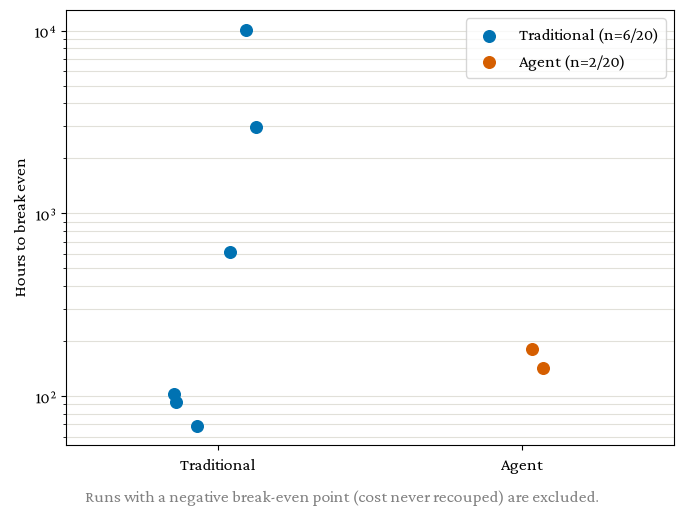

In [6]:
rng = np.random.default_rng(0)
COLORS = {'traditional': COLOR_PALLETTE['blue'], 'agent': COLOR_PALLETTE['orange']}

with plt.rc_context(FONTS):
    fig, ax = plt.subplots(figsize=(7, 5))

    for i, ai_type in enumerate(('traditional', 'agent'), start=1):
        pts = break_even_points[ai_type]
        x = i + rng.uniform(-0.15, 0.15, size=len(pts))
        ax.scatter(x, pts, color=COLORS[ai_type], s=70, zorder=3,
                   label=f"{ai_type.capitalize()} (n={len(pts)}/{n_total[ai_type]})")

    ax.set_yscale("log")
    ax.set_ylabel("Hours to break even")
    ax.set_xlim(0.5, 2.5)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Traditional", "Agent"])
    ax.grid(axis="y", which="both", color="#e1e0d9", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.legend()

    fig.text(0.5, -0.02,
              "Runs with a negative break-even point (cost never recouped) are excluded.",
              ha="center", fontsize=12, color="gray")

    fig.tight_layout()
    plt.show()
